# Hello World Graph

In [1]:
from pydantic import BaseModel,field_validator
from typing import Optional
from langgraph.graph import StateGraph

## we create an Agent state- the shared datastructure that keeps of all the information avaialble in the application

In [3]:
class AgentState(BaseModel):
    message : str
    
    @field_validator('message')
    def validate_message(cls, v):
        if v is None or not isinstance(v, str):
            raise ValueError('message should not be None')
        return v

def greeting_node(state:AgentState) -> AgentState:
    """
    Simple node that adds a greeting message to the state.
    """
    print(type(state.message))
    state.message = f"Hey {state.message}, how is your day going?"
    return state


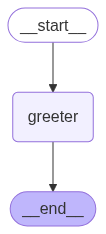

In [4]:
graph = StateGraph(AgentState)
graph.add_node("greeter",greeting_node)
graph.set_entry_point(key="greeter")
graph.set_finish_point(key="greeter")
app = graph.compile()
app

In [5]:
result=app.invoke({"message":"user1"})
result['message']

<class 'str'>


'Hey user1, how is your day going?'

# Multiple Inputs


In [6]:
from typing import List

class AgentState(BaseModel):
    values: List[int]
    name: str
    operation:str
    result: Optional[str]= None

In [7]:
def process_values(state: AgentState) -> AgentState:
    """
    This function handles multiple different inputs
    """
    if(state.operation=="+"):
        state.result = f"Hi there {state.name}! your sum = {sum(state.values)}"
    elif(state.operation=="*"):
        state.result = f"Hi there {state.name}! your product = {(state.values)}"

    return state

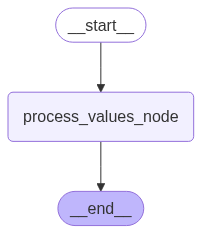

In [8]:
graph = StateGraph(AgentState)
graph.add_node("process_values_node",process_values)
graph.set_entry_point(key="process_values_node")
graph.set_finish_point(key="process_values_node")
app = graph.compile()
app

In [9]:
answers=app.invoke({"values":[1,2,3,4],"name":"visakh","operation":'+'})
answers

{'values': [1, 2, 3, 4],
 'name': 'visakh',
 'operation': '+',
 'result': 'Hi there visakh! your sum = 10'}

In [10]:
app.invoke({"values":[1,2,3,4],"name":"visakh","operation":'*'})

{'values': [1, 2, 3, 4],
 'name': 'visakh',
 'operation': '*',
 'result': 'Hi there visakh! your product = [1, 2, 3, 4]'}

# Conditional

In [34]:
from typing import Literal
from langgraph.graph import StateGraph, START, END
class AgentState(BaseModel):
    number1: int 
    operation: Literal["+", "-"]
    number2: int
    finalNumber: int=0
    
    
def adder(state: AgentState) -> AgentState:
    """This node adds the 2 numbers."""
    print("adder")
    state.finalNumber = state.number1 + state.number2
    return state

def subtractor(state: AgentState) -> AgentState:
    """This node subtracts the 2 numbers."""
    print("subtractor")
    state.finalNumber = state.number1 - state.number2
    return state

def decide_next_node(state: AgentState) -> str:
    """This node selects the next phase based on the operation."""
    if state.operation == "+":
        return "addition_operation"
    elif state.operation == "-":
        print("SUB")
        return "subtraction_operation"

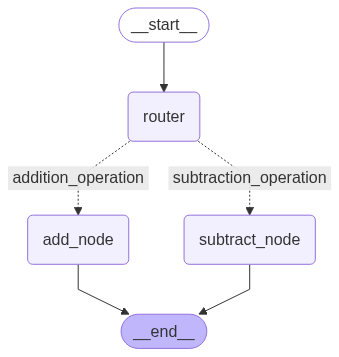

In [35]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
#input is a state, output is a state
graph.add_node("router", lambda state:state) 
graph.add_edge(START,"router")
graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }
)
app=graph.compile()
app

In [37]:
example1={"number1":2,"operation":"+","number2":4}
example2={"number1":2,"operation":"-","number2":4}
example3={"number1":2,"operation":"/","number2":4}
for example in [example1,example2,example3]:
    print(app.invoke(example))

adder
{'number1': 2, 'operation': '+', 'number2': 4, 'finalNumber': 6}
SUB
subtractor
{'number1': 2, 'operation': '-', 'number2': 4, 'finalNumber': -2}


ValidationError: 1 validation error for AgentState
operation
  Input should be '+' or '-' [type=literal_error, input_value='/', input_type=str]
    For further information visit https://errors.pydantic.dev/2.11/v/literal_error

# Looping Graph